# 预训练语义分割模型预测-单张图像-Python API

同济子豪兄：https://space.bilibili.com/1900783

2022-1-11 2023-8-16

## 进入 mmsegmentation 主目录

In [1]:
# import os
# os.chdir('mmsegmentation')

# 进入主目录
import os
# 切换到上一级目录（即 mmsegmentation 文件夹）
os.chdir('..')
# 验证当前工作目录
print("当前工作目录:", os.getcwd())  # 输出: 

当前工作目录: E:\bishe_demo\mmsegmentation-main


## 导入工具包

In [2]:
import numpy as np
import cv2

from mmseg.apis import init_model, inference_model, show_result_pyplot
import mmcv

import matplotlib.pyplot as plt
%matplotlib inline

## 载入模型

In [3]:
# # 模型 config 配置文件
# config_file = 'configs/segformer/segformer_mit-b5_8xb1-160k_cityscapes-1024x1024.py'
# 
# # 模型 checkpoint 权重文件
# checkpoint_file = 'https://download.openmmlab.com/mmsegmentation/v0.5/segformer/segformer_mit-b5_8x1_1024x1024_160k_cityscapes/segformer_mit-b5_8x1_1024x1024_160k_cityscapes_20211206_072934-87a052ec.pth'

#我用的MIT-B1
# 模型 config 配置文件
config_file = 'configs/segformer/segformer_mit-b1_8xb1-160k_cityscapes-1024x1024.py'

# 模型 checkpoint 权重文件
checkpoint_file = 'segformer_mit-b1_8x1_1024x1024_160k_cityscapes_20211208_064213-655c7b3f.pth'


In [5]:
from mmseg.models import CrossEntropyLoss

loss = CrossEntropyLoss(avg_non_ignore=True)

model = init_model(config_file, checkpoint_file, device='cuda:0')

Loads checkpoint by local backend from path: segformer_mit-b1_8x1_1024x1024_160k_cityscapes_20211208_064213-655c7b3f.pth


## 载入测试图像

In [6]:
img_path = 'data/street_uk.jpeg'

In [7]:
img_bgr = cv2.imread(img_path)

In [8]:
img_bgr.shape

(1500, 2250, 3)

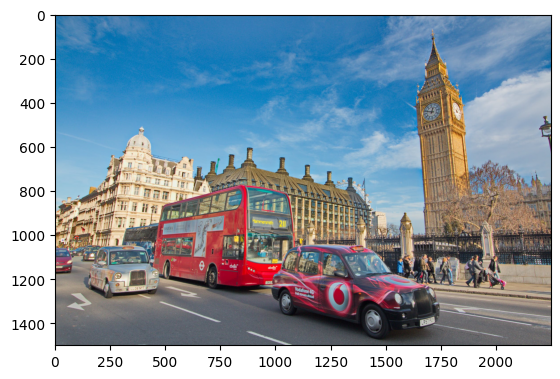

In [9]:
plt.imshow(img_bgr[:,:,::-1])
plt.show()

## 语义分割推理预测

In [10]:
result = inference_model(model, img_bgr)

In [11]:
# result

In [11]:
result.keys()

['pred_sem_seg', 'seg_logits']

## 语义分割预测结果-定性类别

In [12]:
# 类别：0-18，共 19 个 类别
result.pred_sem_seg.data.shape

torch.Size([1, 1500, 2250])

In [13]:
np.unique(result.pred_sem_seg.data.cpu())

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8, 10, 11, 12, 13, 15, 16, 17, 18],
      dtype=int64)

In [14]:
result.pred_sem_seg.data.shape

torch.Size([1, 1500, 2250])

In [15]:
result.pred_sem_seg.data

tensor([[[10, 10, 10,  ..., 10, 10, 10],
         [10, 10, 10,  ..., 10, 10, 10],
         [10, 10, 10,  ..., 10, 10, 10],
         ...,
         [ 0,  0,  0,  ...,  0,  0,  0],
         [ 0,  0,  0,  ...,  0,  0,  0],
         [ 0,  0,  0,  ...,  0,  0,  0]]], device='cuda:0')

In [16]:
pred_mask = result.pred_sem_seg.data[0].detach().cpu().numpy()

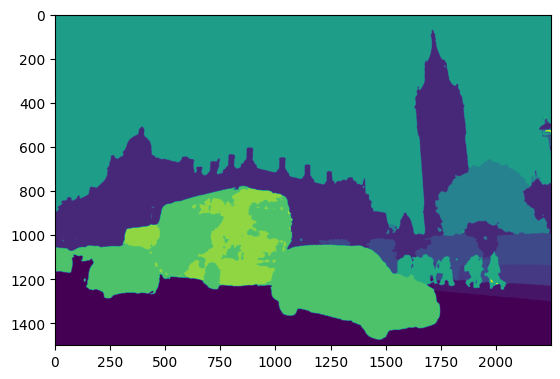

In [17]:
plt.imshow(pred_mask)
plt.show()

## 语义分割预测结果-定量置信度

In [18]:
# 置信度
result.seg_logits.data.shape

torch.Size([19, 1500, 2250])

## 可视化语义分割预测结果-方法一

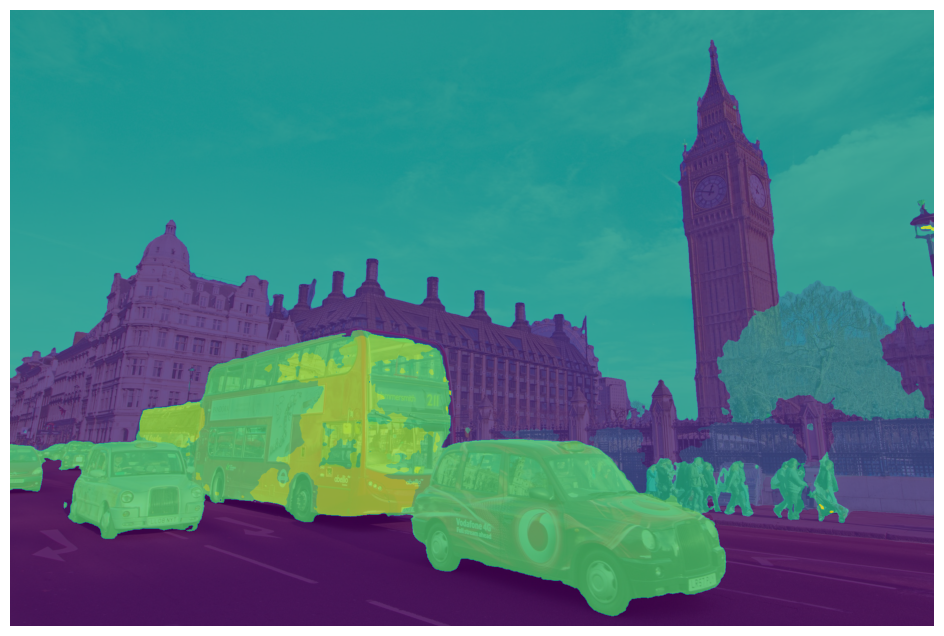

In [20]:
plt.figure(figsize=(14, 8))
plt.imshow(img_bgr[:,:,::-1])
plt.imshow(pred_mask, alpha=0.8) # alpha 高亮区域透明度，越小越接近原图
plt.axis('off')
plt.savefig('outputs/B2-1.jpg')
plt.show()

## 可视化语义分割预测结果-方法二（和原图并排显示）

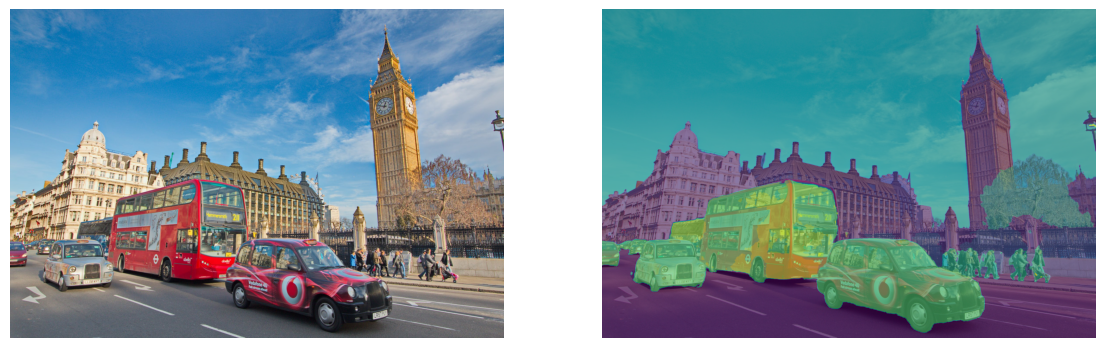

In [21]:
plt.figure(figsize=(14, 8))

plt.subplot(1,2,1)
plt.imshow(img_bgr[:,:,::-1])
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_bgr[:,:,::-1])
plt.imshow(pred_mask, alpha=0.6) # alpha 高亮区域透明度，越小越接近原图
plt.axis('off')
plt.savefig('outputs/B2-2.jpg')
plt.show()

## 可视化语义分割预测结果-方法三

按照`mmseg/datasets/cityscapes.py`定义的配色方案

In [22]:
from mmseg.apis import show_result_pyplot

In [23]:
img_viz = show_result_pyplot(model, img_path, result, opacity=0.8, title='MMSeg', out_file='outputs/B2-3.jpg')

E:\anaconda3\envs\openmmlab\lib\site-packages\mmengine\visualization\visualizer.py:196: UserWarning: Failed to add <class 'mmengine.visualization.vis_backend.LocalVisBackend'>, please provide the `save_dir` argument.
  warnings.warn(f'Failed to add {vis_backend.__class__}, '


opacity控制透明度，越小，越接近原图。

In [24]:
img_viz.shape

(1500, 2250, 3)

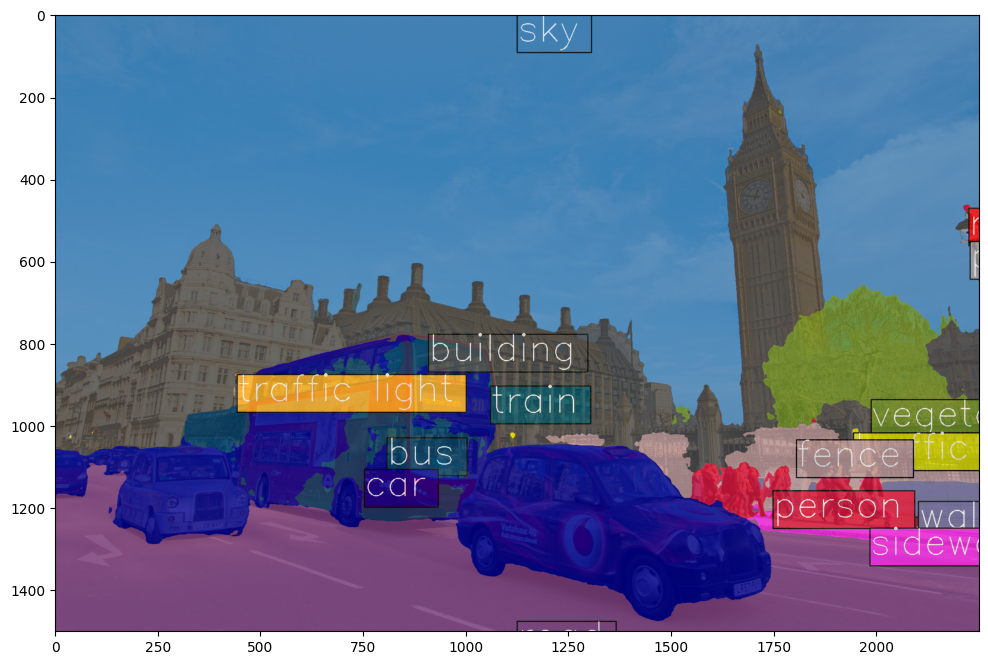

In [25]:
plt.figure(figsize=(14, 8))
plt.imshow(img_viz)
plt.show()

## 可视化语义分割预测结果-方法四（加图例）

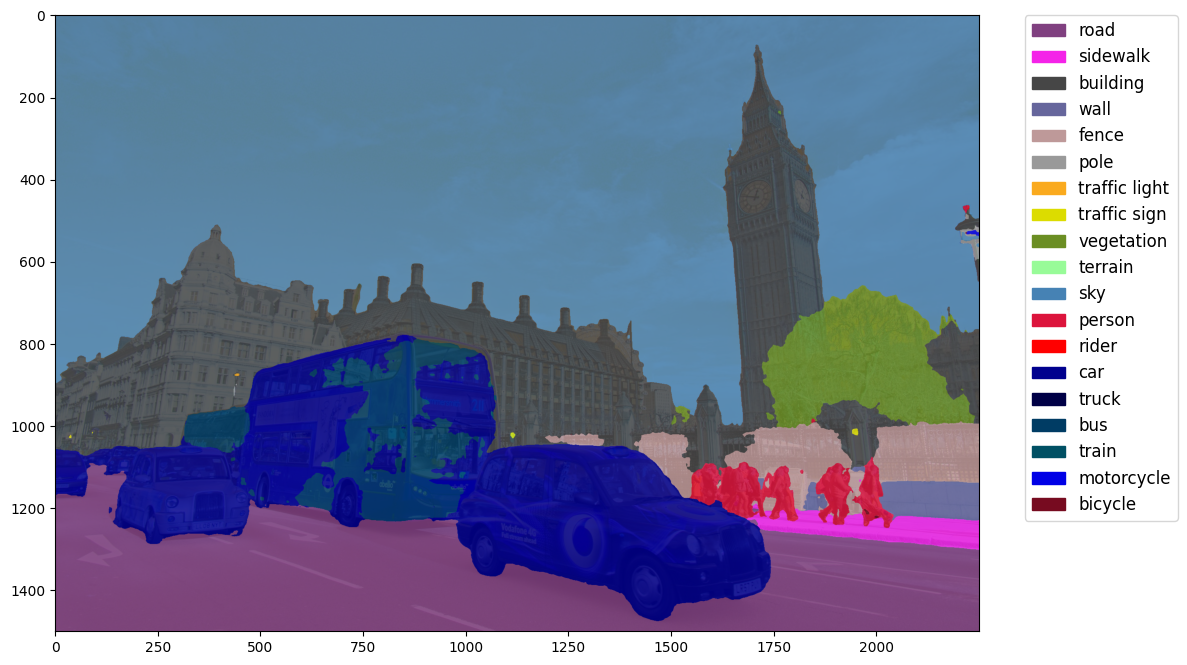

In [26]:
from mmseg.datasets import cityscapes
import numpy as np
import mmcv 
from PIL import Image

# 获取类别名和调色板
classes = cityscapes.CityscapesDataset.METAINFO['classes']
palette = cityscapes.CityscapesDataset.METAINFO['palette']
opacity = 0.15 # 透明度，越大越接近原图

# 将分割图按调色板染色
# seg_map = result[0].astype('uint8')
seg_map = pred_mask.astype('uint8')
seg_img = Image.fromarray(seg_map).convert('P')
seg_img.putpalette(np.array(palette, dtype=np.uint8))

from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
plt.figure(figsize=(14, 8))
im = plt.imshow(((np.array(seg_img.convert('RGB')))*(1-opacity) + mmcv.imread(img_path)*opacity) / 255)

# 为每一种颜色创建一个图例
patches = [mpatches.Patch(color=np.array(palette[i])/255., label=classes[i]) for i in range(len(classes))]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize='large')

plt.savefig('outputs/B2-4.jpg')
plt.show()